In [1]:
from huggingface_hub import login
import pandas as pd
from datasets import load_dataset
import zstandard as zstd
import requests
import io
import json
import random
import numpy as np
import re

login()

# Ensure reproducibility
random.seed(42)

/home3/s5056950/code/DATA_PRIVACY/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load the data from Hugginface. We use two different repos: one for the train split, one for the test split

In [53]:
TRAIN_ROWS_NEEDED = 5000 # True Members
TEST_ROWS_NEEDED = 5000   # True Non-Members
DOMAIN = "PubMed Abstracts" # domain

min_length = 600
max_length = 1600

TOPICS = {
    "gene", "genes", "genetic", "genetics", "genomic", "genomics",
    "genome", "mutation", "mutations", "mutant", "allele", "alleles",
    "chromosome", "chromosomal", "chromosomes", "dna", "rna",
    "protein", "proteins", "molecular", "cell", "cells", "cellular" 
}

# Pre-compile a single regex with word boundaries for fast matching
TOPIC_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(term) for term in TOPICS) + r')\b', 
    re.IGNORECASE
)

# function to filter the domain
def filter(example):
    # 1. Base filters
    if example.get("meta", {}).get("pile_set_name") != DOMAIN:
        return False
    if not (min_length <= len(example["text"]) <= max_length):
        return False
        
    # 2. Check for at least 1 match
    return bool(TOPIC_PATTERN.search(example["text"]))

# TRAIN DATA (MEMBERS)
# https://huggingface.co/datasets/monology/pile-uncopyrighted


print(f"--- Fetching {TRAIN_ROWS_NEEDED} Train Rows (Members) ---")

# 1. Load the streaming Parquet branch
train_dataset = load_dataset(
    "monology/pile-uncopyrighted", 
    split="train", 
    revision="refs/convert/parquet", 
    streaming=True
)


domain_train_stream = train_dataset.filter(filter).shuffle(seed=42, buffer_size=10000)
train_members_list = list(domain_train_stream.take(TRAIN_ROWS_NEEDED))

# 3. Save to Parquet
df_train = pd.DataFrame(train_members_list)
df_train.to_parquet("../dataset/members.parquet")
print(f"Saved {len(df_train)} rows to dataset/members.parquet\n")


# TEST DATA (NON-MEMBERS)
# https://huggingface.co/datasets/mit-han-lab/pile-val-backup

print(f"--- Fetching {TEST_ROWS_NEEDED} Test Rows (Non-Members) ---")


# 1. Load the streaming Parquet branch
test_dataset = load_dataset(
    "mit-han-lab/pile-val-backup", 
    split="validation", 
    revision="refs/convert/parquet", 
    streaming=True
)

domain_test_stream = test_dataset.filter(filter).shuffle(seed=42, buffer_size=10000)
test_non_members_list = list(domain_test_stream.take(TEST_ROWS_NEEDED))

# 2. Save to Parquet
df_test = pd.DataFrame(test_non_members_list)
df_test.to_parquet("../dataset/non_members.parquet")
print(f"Saved {len(df_test)} rows to dataset/non_members.parquet\n")

# VERIFICATION
print("--- Final Verification ---")
check_train = pd.read_parquet("../dataset/members.parquet")
check_test = pd.read_parquet("../dataset/non_members.parquet")

print(f"Members Dataset (Train): {check_train.shape[0]} rows")
print(f"Non-Members Dataset (Test): {check_test.shape[0]} rows")

--- Fetching 5000 Train Rows (Members) ---
Saved 5000 rows to dataset/members.parquet

--- Fetching 5000 Test Rows (Non-Members) ---
Saved 5000 rows to dataset/non_members.parquet

--- Final Verification ---
Members Dataset (Train): 5000 rows
Non-Members Dataset (Test): 5000 rows


In [2]:
members = pd.read_parquet("../dataset/members.parquet")
members = members['text']
non_members = pd.read_parquet("../dataset/non_members.parquet")
non_members = non_members['text']

members[0]

'The formation of cognitive maps of adjacent environments: evidence from the head direction cell system.\nIn 2 experiments the authors tested whether the head direction (HD) cell system underlies a sense of direction maintained across environments. In Experiment 1, HD neurons failed to maintain their firing directions across T mazes in adjacent environments but rather reoriented to the T maze within each environment. Such reorientation suggests that familiar landmarks override an internal directional sense, so in Experiment 2 the authors recorded HD neurons as rats walked between novel and familiar "rooms" of a 4-chamber apparatus. In novel rooms, HD neurons maintained the firing direction of the preceding environment. However, in familiar rooms, HD neuron firing directions shifted to agree with the landmarks therein. With repeated experience, a homogeneous representation of all rooms developed in a subset of the rats.'

## 1. data leakage check.
since the members and non-members should, by definition, be completely separate dataset, we want to make sure that there is ovelap between them. 

In [3]:
# normalize the strings to cancel out differences like upper and lower case use
def normalize(series):
    return (
        series.astype(str)
              .str.strip()
              .str.lower()
              .str.replace(r'\s+', ' ', regex=True)
    )

clean_members = normalize(members)
clean_non_members = normalize(non_members)

# Find clean matches
matches = set(clean_members).intersection(clean_non_members)
print(f"matches: {len(matches)}")

matches: 0


## tokenize

In [4]:
# per-word token
# we split each string into singular words (e.g. 'we', 'split', 'each', ...)
m_tokens = members.astype(str).str.split()
nm_tokens = non_members.astype(str).str.split()

## 2. Time
there is no metadata that reports the time for the samples. However, we checked the actual text for time references.
The samples that contained time references were around 300. Since their presence could make the two datasets more distinguishable from each other, we dropped them.

In [5]:
import re

YEAR_PATTERN = re.compile(r"^(18|19|20)\d{2}$")

# check each token for information about years (e.g. 1988, 2006, ...)
def get_year_indices(tokens_series):
    has_year = tokens_series.apply(
        lambda tokens: any(bool(YEAR_PATTERN.match(tok)) for tok in tokens)
    )
    return has_year[has_year].index.tolist()


# extract the indices of samples with information about time
m_years = get_year_indices(m_tokens)
nm_years = get_year_indices(nm_tokens)

print(f"members have {len(m_years)} mentions of years")
print(f"non-members have {len(nm_years)} mentions of years")

# because the samples with time reference are a small portion of the data, we can simply remove them
# we drop the samples both from the original dataset and the tokenized dataset

m_tokens = m_tokens.drop(index = m_years)
members = members.drop(index = m_years)

# drop samples with time reference
nm_tokens = nm_tokens.drop(index = nm_years)
non_members = non_members.drop(index = nm_years)


members have 133 mentions of years
non-members have 110 mentions of years


actually remove samples with time references from parquet files

In [6]:
# turn it back from tokenized text to plain text
members = m_tokens.apply(lambda tokens: " ".join(tokens))
non_members = nm_tokens.apply(lambda tokens: " ".join(tokens))

# turn into dataframe
members_df = pd.DataFrame({"text": members})
non_members_df = pd.DataFrame({"text": non_members})

# save to parquet
members_df.to_parquet("../dataset/members.parquet", index=False)
non_members_df.to_parquet("../dataset/non_members.parquet", index=False)

## 3. Length
We compare the length of the members and non-members to check they come from the same distribution

In [61]:
# store the length of each tokenized string
m_lengths = []
nm_lengths = []

for m, nm in zip(m_tokens, nm_tokens):
    m_lengths.append(len(m))
    nm_lengths.append(len(nm))


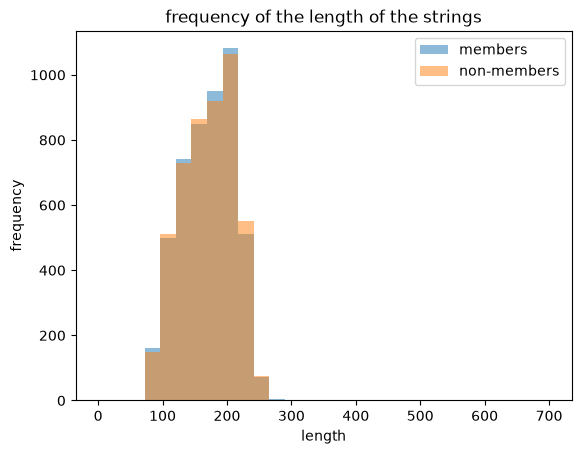

In [62]:
import matplotlib.pyplot as plt

# plot the frequency of the length of each sample
# the ditributions mostly overlap

bins = np.linspace(0, 700, 30)

plt.hist(m_lengths, bins, alpha=0.5, label='members')
plt.hist(nm_lengths, bins, alpha=0.5, label='non-members')
plt.xlabel("length")
plt.ylabel("frequency")
plt.legend(loc='upper right')
plt.title("frequency of the length of the strings")
plt.show()

In [63]:
# mean and median

data = {
  "mean": [np.mean(m_lengths), np.mean(nm_lengths)],
  "median": [np.median(m_lengths), np.median(nm_lengths)]
}

length_stats = pd.DataFrame(data, index = ["members", "non-members"])

print(length_stats)

                   mean  median
members      170.426546   173.0
non-members  170.981097   173.0


In [64]:
# 2 sample test
# because the p value > 0.05, we fail to reject the null hypothesis
# this means that there is no significant difference between the lengths of members and non-members

import scipy.stats as stats

print(np.var(m_lengths), np.var(nm_lengths))

print(stats.ttest_ind(a=m_lengths, b=nm_lengths, equal_var=True))

1624.1858414301203 1624.2922253834051
TtestResult(statistic=np.float64(-0.6787152715151941), pvalue=np.float64(0.497334426909078), df=np.float64(9732.0))


## 4. Domain and source

Since we loaded the data directly from Huggingface and filtered it by domain, we are sure that both members and non-members share the same domain

## 5. Surface statistics

5.1 vocabulary overlap

In [66]:
from itertools import chain

# make sets from all the words
# use chain.from_iterable because each sample is a list of tokens
vocab_m = set(chain.from_iterable(m_tokens))
vocab_nm = set(chain.from_iterable(nm_tokens))

# words appearing in both datasets
common_words = vocab_m.intersection(vocab_nm)

# 4. Total combined vocabulary (union)
total_vocab = vocab_m | vocab_nm

print(f"Shared words: {len(common_words)}")
print(f"Total words: {len(total_vocab)}")

similarity = len(common_words) / len(total_vocab)
print(f"Vocabulary Overlap: common words / total words = {similarity:.2%}")

Shared words: 33086
Total words: 135871
Vocabulary Overlap: common words / total words = 24.35%


5.2 type-token ratio: diversity of the vocabulary

In [67]:
# to compute the type token ratio we use:
# the n. of unique words:  len(vocab_m)
# the n. of total words: m_tokens.str.len().sum()
# we compute the ratio between them

m_type = len(vocab_m) / m_tokens.str.len().sum()
print(f"type-token ratio for members: {m_type:.3%}")


nm_type = len(vocab_nm) / nm_tokens.str.len().sum()
print(f"type-token ratio for non-members: {nm_type:.3%}")

type-token ratio for members: 10.188%
type-token ratio for non-members: 10.102%


5.3 frequency of structural markers

In [68]:
# patterns that might come up in Pubmed abstracts
PATTERNS = {
    "background": re.compile(
        r"\b(background|introduction|rationale|objective|aims?)\b[:\s]",
        re.I,
    ),
    "methods": re.compile(
        r"\b(methods?|methodology|materials? and methods?|study design|patients and methods)\b[:\s]",
        re.I,
    ),
    "results": re.compile(
        r"\b(results?|findings?|outcomes?)\b[:\s]", re.I
    ),
    "conclusions": re.compile(
        r"\b(conclusions?|discussion|significance|implications)\b[:\s]", re.I
    ),
}

In [69]:
# looks at whether a specific pattern appears at least once in a sample
def find_pattern(text):
    text_str = str(text)
    return {
        section: bool(pattern.search(text_str))
        for section, pattern in PATTERNS.items()
    }


# compute presence of pattern for both datasets and take the mean
m_stats = members.apply(find_pattern).apply(pd.Series).mean()
nm_stats = non_members.apply(find_pattern).apply(pd.Series).mean()

# make dataframe for visualization
comparison_df = pd.DataFrame({
    "Members (%)": (m_stats * 100).round(2),
    "Non-Members (%)": (nm_stats * 100).round(2),
})


print(comparison_df)

             Members (%)  Non-Members (%)
background          5.94             6.63
methods             9.70             9.73
results            32.67            33.13
conclusions         3.80             3.76


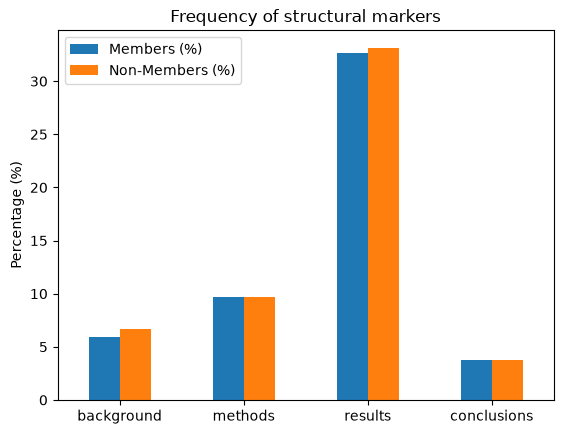

In [70]:
comparison_df[["Members (%)", "Non-Members (%)"]].plot(kind="bar")

plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.title("Frequency of structural markers")
plt.show()

## Blind baseline

concatenate datasets and add labels to them

In [15]:
# Concatenate texts
texts = pd.concat([members, non_members], ignore_index=True)

# Create corresponding labels (1 for members, 0 for non-members)
labels = [1] * len(members) + [0] * len(non_members)

# Combine into a single DataFrame
df = pd.DataFrame({"text": texts, "label": labels})

In [16]:
X = df['text']
y = df['label']

split into train and test sets

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

vectorize the text

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# vectorize the text 
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

make the Logistic Regression model

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [ ]:
# probabilities for each prediction
y_score = model.predict_proba(X_test.toarray())

In [54]:
from sklearn.metrics import roc_auc_score

# auc score
auc = roc_auc_score(y_test, y_score[:, 1])
print(f"AUC score: {auc}")

AUC score: 0.5119914170174136


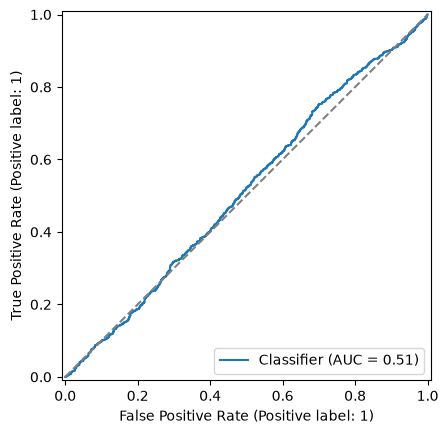

In [56]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve 
RocCurveDisplay.from_predictions(y_test, y_score[:, 1])

# add baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()